<a href="https://colab.research.google.com/github/Ayon150/AI_-_DL/blob/main/AI_%26_DL_ASSIGNMENT_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


===== PART A =====

1. Output (No padding, stride=2):
 [[ 0. -2.]
 [-2.  3.]]

2. Output (Padding=1, stride=2):
 [[-1. -1. -1.]
 [ 1. -2.  1.]
 [ 1.  3.  0.]]

3. Depthwise Output:
 [[[ 0.  0.]
  [ 0.  2.]
  [-2.  0.]]

 [[ 2. -2.]
  [-2.  0.]
  [ 1.  2.]]

 [[-2.  0.]
  [ 0. -2.]
  [ 3.  0.]]]

===== PART B =====


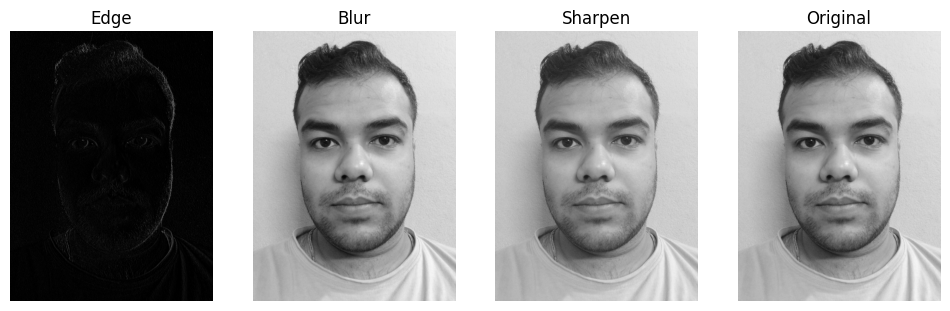


===== PART C =====
Separable kernels: 10
Non-separable kernels: 10

===== PART D =====
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


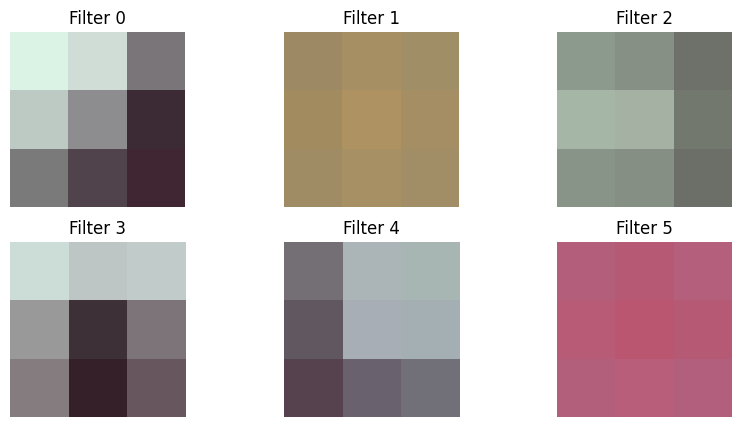


Observation: Some filters resemble edge detectors (Sobel-like)


In [1]:
# ==========================================================
# SETUP
# ==========================================================
import numpy as np
import matplotlib.pyplot as plt
import cv2

from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model

# ==========================================================
# PART A: FEATURE MAP COMPUTATION
# ==========================================================

print("\n===== PART A =====")

# Input feature map (4x4x2)
input_ch1 = np.array([
    [1,2,0,1],
    [3,1,2,2],
    [0,1,3,1],
    [2,2,1,0]
])

input_ch2 = np.array([
    [0,1,2,1],
    [1,0,1,2],
    [2,1,0,1],
    [1,2,1,0]
])

input_feature = np.stack([input_ch1, input_ch2], axis=-1)

# Kernel (2x2x2)
kernel_ch1 = np.array([[1,0],[0,-1]])
kernel_ch2 = np.array([[0,1],[-1,0]])

kernel = np.stack([kernel_ch1, kernel_ch2], axis=-1)

# -------- 1. Regular Convolution (stride=2, no padding) --------
def conv2d(input_f, kernel, stride=2):
    H, W, C = input_f.shape
    k = kernel.shape[0]

    out_h = (H - k)//stride + 1
    out_w = (W - k)//stride + 1

    output = np.zeros((out_h, out_w))

    for i in range(out_h):
        for j in range(out_w):
            region = input_f[i*stride:i*stride+k, j*stride:j*stride+k, :]
            output[i,j] = np.sum(region * kernel)

    return output

out1 = conv2d(input_feature, kernel, stride=2)
print("\n1. Output (No padding, stride=2):\n", out1)

# -------- 2. With padding --------
def pad_input(x, pad=1):
    return np.pad(x, ((pad,pad),(pad,pad),(0,0)), mode='constant')

padded = pad_input(input_feature, 1)
out2 = conv2d(padded, kernel, stride=2)

print("\n2. Output (Padding=1, stride=2):\n", out2)

# -------- 3. Depthwise Convolution --------
def depthwise_conv(input_f, kernel, stride=1):
    H, W, C = input_f.shape
    k = kernel.shape[0]

    out_h = (H - k)//stride + 1
    out_w = (W - k)//stride + 1

    output = np.zeros((out_h, out_w, C))

    for c in range(C):
        for i in range(out_h):
            for j in range(out_w):
                region = input_f[i:i+k, j:j+k, c]
                output[i,j,c] = np.sum(region * kernel[:,:,c])

    return output

out3 = depthwise_conv(input_feature, kernel, stride=1)
print("\n3. Depthwise Output:\n", out3)

# ==========================================================
# PART B: CUSTOM KERNEL DESIGN & VISUALIZATION
# ==========================================================

print("\n===== PART B =====")

# Upload your image manually in Colab before running
img = cv2.imread('/content/face.jpeg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Kernels
edge_kernel = np.array([[-1,0,1],[-2,0,2],[-1,0,1]])
blur_kernel = np.ones((3,3))/9
sharpen_kernel = np.array([[0,-1,0],[-1,5,-1],[0,-1,0]])

kernels = {
    "Edge": edge_kernel,
    "Blur": blur_kernel,
    "Sharpen": sharpen_kernel
}

plt.figure(figsize=(12,5))

for i,(name,kernel) in enumerate(kernels.items()):
    filtered = cv2.filter2D(img, -1, kernel)

    plt.subplot(1,4,i+1)
    plt.imshow(filtered, cmap='gray')
    plt.title(name)
    plt.axis('off')

plt.subplot(1,4,4)
plt.imshow(img, cmap='gray')
plt.title("Original")
plt.axis('off')

plt.show()

# ==========================================================
# PART C: SPATIAL SEPARABILITY
# ==========================================================

print("\n===== PART C =====")

# Separable kernels
separable_kernels = [
    np.outer([1,1],[1,1]),
    np.outer([1,2,1],[1,2,1]),
    np.outer([1,0,-1],[1,2,1]),
    np.outer([1,1,1],[1,0,-1]),
    np.outer([1,2,3],[1,0,1]),
    np.outer([2,1,0],[1,2,1]),
    np.outer([1,3,1],[1,1,1]),
    np.outer([1,0,1],[1,2,1]),
    np.outer([2,2,2],[1,0,-1]),
    np.outer([1,4,1],[1,2,1])
]

# Non-separable kernels
non_separable_kernels = [
    np.array([[1,2],[3,4]]),
    np.array([[0,1,2],[2,1,0],[1,0,2]]),
    np.array([[1,0,1],[0,1,0],[1,0,1]]),
    np.array([[2,3,1],[4,1,5],[1,2,3]]),
    np.array([[1,2,3],[4,5,6],[7,8,9]]),
    np.random.rand(3,3),
    np.random.rand(3,3),
    np.random.rand(3,3),
    np.random.rand(3,3),
    np.random.rand(3,3)
]

print("Separable kernels:", len(separable_kernels))
print("Non-separable kernels:", len(non_separable_kernels))

# ==========================================================
# PART D: CNN KERNEL LEARNING
# ==========================================================

print("\n===== PART D =====")

# Load VGG16
model = VGG16(weights='imagenet', include_top=False)

# Extract first conv layer filters
filters, biases = model.layers[1].get_weights()

# Normalize filters
f_min, f_max = filters.min(), filters.max()
filters = (filters - f_min) / (f_max - f_min)

# Plot filters
plt.figure(figsize=(10,5))
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(filters[:,:,:,i])
    plt.title(f"Filter {i}")
    plt.axis('off')

plt.show()

print("\nObservation: Some filters resemble edge detectors (Sobel-like)")